# distribucion binomial

In [2]:
install.packages(c("ggplot2", "gridExtra", "scales"))

Installing packages into ‘/home/patricioaraneda/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)




ANÁLISIS BINOMIAL: n = 20, p = 0.10

📊 ESTADÍSTICOS TEÓRICOS:
   Media (μ)     : 2.000 pacientes
   Varianza (σ²) : 1.800
   Desv. Est. (σ): 1.342

🎯 PROBABILIDADES PUNTUALES P(X = k) [dbinom()]:
   P(X =  0) = 0.1216  (12.16%)
   P(X =  1) = 0.2702  (27.02%)
   P(X =  2) = 0.2852  (28.52%)
   P(X =  3) = 0.1901  (19.01%)
   P(X =  5) = 0.0319  (3.19%)

📈 PROBABILIDADES ACUMULADAS P(X ≤ k) [pbinom()]:
   P(X ≤  1) = 0.3917  (39.17%)
   P(X ≤  2) = 0.6769  (67.69%)
   P(X ≤  3) = 0.8670  (86.70%)
   P(X ≤  4) = 0.9568  (95.68%)

⚠️  PROBABILIDADES DE COLA P(X ≥ k):
   P(X ≥  3) = 0.3231  (32.31%)
   P(X ≥  4) = 0.1330  (13.30%)
   P(X ≥  5) = 0.0432  (4.32%)

🔍 PROBABILIDAD DE RANGO P(1 ≤ X ≤ 3):
   P(1 ≤ X ≤ 3) = 0.7455  (74.55%)
TableGrob (3 x 2) "arrange": 5 grobs
  z     cells    name                 grob
1 1 (2-2,1-1) arrange       gtable[layout]
2 2 (2-2,2-2) arrange       gtable[layout]
3 3 (3-3,1-1) arrange       gtable[layout]
4 4 (3-3,2-2) arrange       gtable[layout]
5 5 (1-

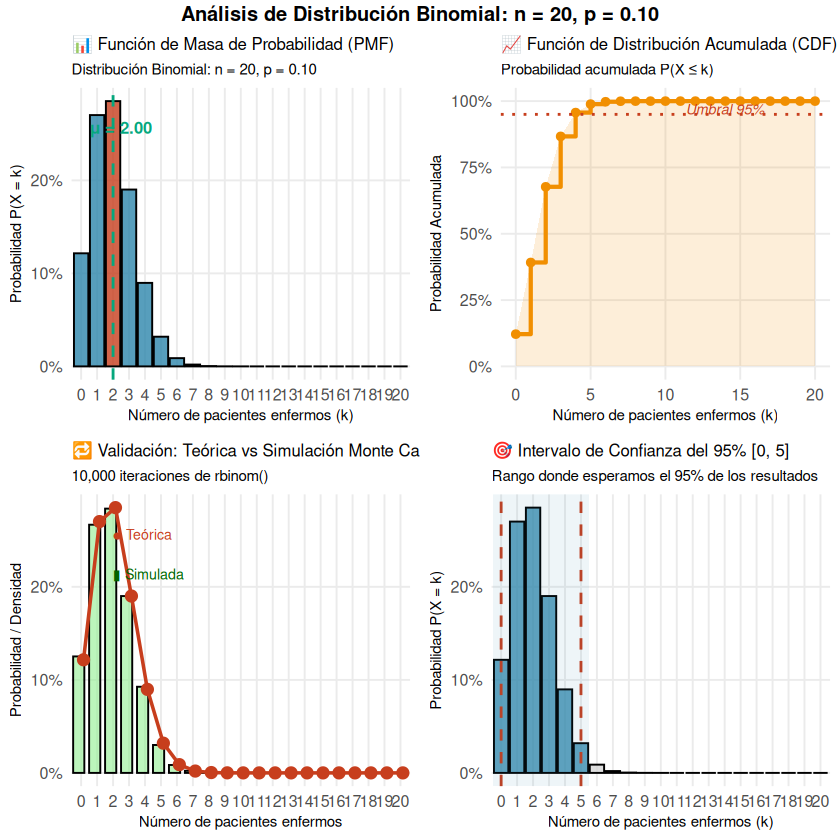

In [9]:
# -*- coding: utf-8 -*-
# ============================================================================
# ANÁLISIS DE DISTRIBUCIÓN BINOMIAL EN R
# Estudio de Prevalencia de Enfermedad
# ============================================================================
# Escenario:
#   • Prevalencia poblacional: p = 0.1 (10%)
#   • Tamaño de cohorte: n = 20 pacientes
#
# Este script calcula probabilidades clave y genera visualizaciones
# para apoyar la toma de decisiones en investigación epidemiológica.
# ============================================================================

# Instalar paquetes si es necesario (descomentar la primera vez)
# install.packages(c("ggplot2", "gridExtra", "scales"))

library(ggplot2)
library(gridExtra)
library(scales)

# Configuración global de temas para ggplot2
theme_set(theme_minimal(base_size = 12))
colors <- list(
    primary = "#2E86AB",
    secondary = "#A23B72",
    highlight = "#F18F01",
    success = "#06A77D",
    danger = "#C73E1D"
)

# ============================================================================
# FUNCIÓN 1: Calcular probabilidades clave
# ============================================================================
calcular_probabilidades <- function(n, p) {
    cat("\n", rep("=", 60), "\n", sep = "")
    cat(sprintf("ANÁLISIS BINOMIAL: n = %d, p = %.2f\n", n, p))
    cat(rep("=", 60), "\n", sep = "")

    # Estadísticos descriptivos
    media <- n * p
    varianza <- n * p * (1 - p)
    desv_std <- sqrt(varianza)

    cat("\n📊 ESTADÍSTICOS TEÓRICOS:\n")
    cat(sprintf("   Media (μ)     : %.3f pacientes\n", media))
    cat(sprintf("   Varianza (σ²) : %.3f\n", varianza))
    cat(sprintf("   Desv. Est. (σ): %.3f\n", desv_std))

    # Probabilidades puntuales: P(X = k) usando dbinom()
    cat("\n🎯 PROBABILIDADES PUNTUALES P(X = k) [dbinom()]:\n")
    valores_k <- c(0, 1, 2, 3, 5)
    for (k in valores_k) {
        prob <- dbinom(k, size = n, prob = p)
        cat(sprintf("   P(X = %2d) = %.4f  (%.2f%%)\n", k, prob, prob * 100))
    }

    # Probabilidades acumuladas: P(X ≤ k) usando pbinom()
    cat("\n📈 PROBABILIDADES ACUMULADAS P(X ≤ k) [pbinom()]:\n")
    for (k in c(1, 2, 3, 4)) {
        prob <- pbinom(k, size = n, prob = p)
        cat(sprintf("   P(X ≤ %2d) = %.4f  (%.2f%%)\n", k, prob, prob * 100))
    }

    # Probabilidades de cola superior: P(X ≥ k) = 1 - P(X ≤ k-1)
    cat("\n⚠️  PROBABILIDADES DE COLA P(X ≥ k):\n")
    for (k in c(3, 4, 5)) {
        # Usar lower.tail = FALSE es más estable numéricamente
        prob <- pbinom(k - 1, size = n, prob = p, lower.tail = FALSE)
        cat(sprintf("   P(X ≥ %2d) = %.4f  (%.2f%%)\n", k, prob, prob * 100))
    }

    # Probabilidad de rango: P(a ≤ X ≤ b)
    a <- 1
    b <- 3
    prob_rango <- pbinom(b, size = n, prob = p) - pbinom(a - 1, size = n, prob = p)
    cat(sprintf("\n🔍 PROBABILIDAD DE RANGO P(%d ≤ X ≤ %d):\n", a, b))
    cat(sprintf("   P(%d ≤ X ≤ %d) = %.4f  (%.2f%%)\n", a, b, prob_rango, prob_rango * 100))

    cat(rep("=", 60), "\n", sep = "")

    # Retornar lista con resultados para uso en visualizaciones
    return(list(
        n = n,
        p = p,
        media = media,
        varianza = varianza,
        desv_std = desv_std,
        moda = which.max(dbinom(0:n, size = n, prob = p)) - 1 # -1 porque índices empiezan en 1
    ))
}

# ============================================================================
# FUNCIÓN 2: Generar visualizaciones con ggplot2
# ============================================================================
generar_visualizaciones <- function(n, p, stats) {
    x <- 0:n
    pmf <- dbinom(x, size = n, prob = p)
    cdf <- pbinom(x, size = n, prob = p)

    # --------------------------------------------------------------------------
    # Gráfico 1: PMF - Función de Masa de Probabilidad
    # --------------------------------------------------------------------------
    df_pmf <- data.frame(k = x, prob = pmf)

    p1 <- ggplot(df_pmf, aes(x = factor(k), y = prob)) +
        geom_col(aes(fill = k == stats$moda),
            color = "black", alpha = 0.8, show.legend = FALSE
        ) +
        scale_fill_manual(values = c("FALSE" = colors$primary, "TRUE" = colors$danger)) +
        geom_vline(
            xintercept = stats$media + 1, # +1 porque factor
            color = colors$success, linetype = "dashed", linewidth = 0.8
        ) +
        annotate("text",
            x = stats$media + 1.5, y = max(pmf) * 0.9,
            label = sprintf("μ = %.2f", stats$media),
            color = colors$success, fontface = "bold", size = 3.5
        ) +
        labs(
            title = "📊 Función de Masa de Probabilidad (PMF)",
            subtitle = sprintf("Distribución Binomial: n = %d, p = %.2f", n, p),
            x = "Número de pacientes enfermos (k)",
            y = "Probabilidad P(X = k)"
        ) +
        theme(
            plot.title = element_text(size = 10),
            plot.subtitle = element_text(size = 9),
            axis.title.x = element_text(size = 9),
            axis.title.y = element_text(size = 9)
        ) +
        scale_y_continuous(labels = label_percent(accuracy = 1)) +
        theme(panel.grid.minor = element_blank())

    # --------------------------------------------------------------------------
    # Gráfico 2: CDF - Función de Distribución Acumulada
    # --------------------------------------------------------------------------
    df_cdf <- data.frame(k = x, prob_acum = cdf)

    p2 <- ggplot(df_cdf, aes(x = k, y = prob_acum)) +
        geom_step(color = colors$highlight, linewidth = 1.2, direction = "hv") +
        geom_point(color = colors$highlight, size = 2) +
        geom_ribbon(aes(ymin = 0, ymax = prob_acum),
            fill = colors$highlight, alpha = 0.15
        ) +
        geom_hline(
            yintercept = 0.95, color = colors$danger,
            linetype = "dotted", linewidth = 0.8
        ) +
        annotate("text",
            x = n * 0.7, y = 0.97, label = "Umbral 95%",
            color = colors$danger, fontface = "italic", size = 3
        ) +
        labs(
            title = "📈 Función de Distribución Acumulada (CDF)",
            subtitle = "Probabilidad acumulada P(X ≤ k)",
            x = "Número de pacientes enfermos (k)",
            y = "Probabilidad Acumulada"
        ) +
        theme(
            plot.title = element_text(size = 10),
            plot.subtitle = element_text(size = 9),
            axis.title.x = element_text(size = 9),
            axis.title.y = element_text(size = 9)
        ) +
        scale_y_continuous(labels = label_percent(accuracy = 1), limits = c(0, 1)) +
        theme(panel.grid.minor = element_blank())

    # --------------------------------------------------------------------------
    # Gráfico 3: Validación - Teórica vs Simulación Monte Carlo
    # --------------------------------------------------------------------------
    set.seed(42) # Reproducibilidad
    simulacion <- rbinom(n = 10000, size = n, prob = p)

    # Preparar datos para comparación
    df_sim <- data.frame(
        k = factor(0:n),
        teorica = pmf,
        simulada = as.numeric(table(factor(simulacion, levels = 0:n))) / length(simulacion)
    )

    p3 <- ggplot(df_sim, aes(x = k)) +
        geom_col(aes(y = simulada),
            fill = "lightgreen",
            color = "black", alpha = 0.6, width = 0.7,
            position = position_nudge(x = -0.15)
        ) +
        geom_point(aes(y = teorica),
            color = colors$danger, size = 3,
            position = position_nudge(x = 0.15)
        ) +
        geom_line(aes(y = teorica, group = 1),
            color = colors$danger,
            linewidth = 1, position = position_nudge(x = 0.15)
        ) +
        labs(
            title = "🔁 Validación: Teórica vs Simulación Monte Carlo",
            subtitle = "10,000 iteraciones de rbinom()",
            x = "Número de pacientes enfermos",
            y = "Probabilidad / Densidad"
        ) +
        theme(
            plot.title = element_text(size = 10),
            plot.subtitle = element_text(size = 9),
            axis.title.x = element_text(size = 9),
            axis.title.y = element_text(size = 9)
        ) +
        scale_y_continuous(labels = label_percent(accuracy = 1)) +
        annotate("text",
            x = 3, y = max(pmf) * 0.9,
            label = "● Teórica", color = colors$danger, size = 3, hjust = 0
        ) +
        annotate("text",
            x = 3, y = max(pmf) * 0.75,
            label = "▮ Simulada", color = "darkgreen", size = 3, hjust = 0
        ) +
        theme(panel.grid.minor = element_blank(), legend.position = "none")

    # --------------------------------------------------------------------------
    # Gráfico 4: Intervalo de Confianza del 95%
    # --------------------------------------------------------------------------
    # Calcular percentiles usando qbinom()
    ic_inferior <- qbinom(0.025, size = n, prob = p)
    ic_superior <- qbinom(0.975, size = n, prob = p)

    df_ic <- data.frame(
        k = factor(x),
        prob = pmf,
        en_ic = x >= ic_inferior & x <= ic_superior
    )

    p4 <- ggplot(df_ic, aes(x = k, y = prob)) +
        geom_col(aes(fill = en_ic), color = "black", alpha = 0.75) +
        scale_fill_manual(
            values = c("FALSE" = "lightgray", "TRUE" = colors$primary),
            guide = "none"
        ) +
        geom_vline(
            xintercept = ic_inferior + 1, color = colors$danger,
            linetype = "dashed", linewidth = 0.8
        ) +
        geom_vline(
            xintercept = ic_superior + 1, color = colors$danger,
            linetype = "dashed", linewidth = 0.8
        ) +
        annotate("rect",
            xmin = ic_inferior + 0.5, xmax = ic_superior + 1.5,
            ymin = -Inf, ymax = Inf, fill = colors$primary, alpha = 0.08
        ) +
        labs(
            title = sprintf(
                "🎯 Intervalo de Confianza del 95%% [%d, %d]",
                ic_inferior, ic_superior
            ),
            subtitle = "Rango donde esperamos el 95% de los resultados",
            x = "Número de pacientes enfermos (k)",
            y = "Probabilidad P(X = k)"
        ) +
        theme(
            plot.title = element_text(size = 10),
            plot.subtitle = element_text(size = 9),
            axis.title.x = element_text(size = 9),
            axis.title.y = element_text(size = 9)
        ) +
        scale_y_continuous(labels = label_percent(accuracy = 1)) +
        theme(panel.grid.minor = element_blank())

    # --------------------------------------------------------------------------
    # Mostrar todos los gráficos en una cuadrícula 2x2
    # --------------------------------------------------------------------------
    print(grid.arrange(p1, p2, p3, p4,
        ncol = 2,
        top = grid::textGrob(
            sprintf("Análisis de Distribución Binomial: n = %d, p = %.2f", n, p),
            gp = grid::gpar(fontsize = 12, fontface = "bold")
        )
    ))

    # Retornar valores del IC para impresión
    return(list(ic_inferior = ic_inferior, ic_superior = ic_superior))
}

# ============================================================================
# FUNCIÓN 3: Escenarios de aplicación práctica
# ============================================================================
escenario_aplicado <- function(n, p) {
    cat("\n", paste(rep("💡", 30), collapse = ""), "\n", sep = "")
    cat("ESCENARIOS DE APLICACIÓN PRÁCTICA\n")
    cat(paste(rep("💡", 30), collapse = ""), "\n", sep = "")

    # Escenario 1: ¿Es inusual encontrar 5 o más casos?
    k <- 5
    prob_inusual <- pbinom(k - 1, size = n, prob = p, lower.tail = FALSE)
    cat(sprintf("\n❓ ¿Es inusual observar ≥ %d casos enfermos?\n", k))
    cat(sprintf("   P(X ≥ %d) = %.4f (%.2f%%)\n", k, prob_inusual, prob_inusual * 100))
    if (prob_inusual < 0.05) {
        cat("   ✅ SÍ: Es estadísticamente inusual (p < 0.05)\n")
    } else {
        cat("   ❌ NO: Está dentro de lo esperado por azar\n")
    }

    # Escenario 2: Poder estadístico con prevalencia alternativa
    p_alt <- 0.2
    cat(sprintf(
        "\n❓ Si la verdadera prevalencia fuera %.0f%% (p = %.2f),\n",
        p_alt * 100, p_alt
    ))
    cat(sprintf("   ¿cuál es la probabilidad de observar ≤ %d casos?\n", round(n * p)))
    prob_tipo2 <- pbinom(round(n * p), size = n, prob = p_alt)
    cat(sprintf("   P(X ≤ %d | p = %.2f) = %.4f\n", round(n * p), p_alt, prob_tipo2))
    cat("   → Esto representa un error Tipo II potencial (β)\n")

    # Escenario 3: Cálculo de tamaño muestral
    casos_deseados <- 10
    n_necesario <- ceiling(casos_deseados / p)
    cat(sprintf("\n❓ ¿Cuántos pacientes necesito para esperar ~%d casos?\n", casos_deseados))
    cat(sprintf("   Con p = %.2f, se requieren n ≥ %d pacientes\n", p, n_necesario))

    cat("\n", paste(rep("💡", 30), collapse = ""), "\n", sep = "")
}

# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================
main <- function() {
    # Parámetros del estudio
    n <- 20 # Tamaño de la cohorte
    p <- 0.1 # Prevalencia de la enfermedad

    # 1. Calcular probabilidades clave
    stats <- calcular_probabilidades(n, p)

    # 2. Generar visualizaciones
    ic <- generar_visualizaciones(n, p, stats)

    # Imprimir intervalo de confianza en consola
    cat(sprintf(
        "\n🔐 INTERVALO DE CONFIANZA 95%%: [%d, %d] pacientes\n",
        ic$ic_inferior, ic$ic_superior
    ))
    cat("   Interpretación: En el 95%% de cohortes similares,\n")
    cat(sprintf(
        "   esperaríamos entre %d y %d casos.\n",
        ic$ic_inferior, ic$ic_superior
    ))

    # 3. Aplicar a escenarios de investigación
    escenario_aplicado(n, p)

    cat("\n✨ Análisis completado.\n\n")
}

# ============================================================================
# EJECUTAR SCRIPT
# ============================================================================
if (!interactive()) {
    # Si se ejecuta como script desde línea de comandos
    main()
} else {
    # Si se ejecuta en RStudio o consola interactiva
    cat("🚀 Iniciando análisis de distribución binomial...\n")
    cat("   Presiona Enter para continuar o ejecuta main() manualmente.\n")

    # Para ejecución automática en modo interactivo, descomentar:
    # main()
}
